In [2]:
import pandas as pd


In [5]:
df = pd.read_excel('/content/ventas_limpio.xls')


In [6]:
df['Fecha'] = pd.to_datetime(df['Fecha'])
df['Mes'] = df['Fecha'].dt.month

df.head()

,ID_Venta,Producto,Categoria,Cliente,Fecha,Cantidad,Precio,Tienda,Ciudad,Mes
0,1,Bota,Calzado,Sr(A). DarÃ­o Collado,2023-03-31,1,400,PapelerÃ­a Estrella,Guadalajara,3
1,2,Monitor,TecnologÃ­a,Mtro. Nancy Lucio,2023-03-08,4,100,Techzone,Monterrey,3
2,3,Carpeta,PapelerÃ­a,Humberto MatÃ­as DurÃ¡n,2023-09-26,5,500,Techzone,MÃ©rida,9
3,4,Tenis,Calzado,Rosalia Valdivia,2023-06-13,3,800,Moda Center,MÃ©rida,6
4,5,Falda,Ropa,Minerva JosÃ© Gracia,2023-01-31,2,500,PapelerÃ­a Estrella,MÃ©rida,1


In [3]:
import pandas as pd


In [5]:
df = pd.read_excel('/content/ventas_limpio.xls')


In [6]:
df['Fecha'] = pd.to_datetime(df['Fecha'])
df['Mes'] = df['Fecha'].dt.month

df.head()

,ID_Venta,Producto,Categoria,Cliente,Fecha,Cantidad,Precio,Tienda,Ciudad,Mes
0,1,Bota,Calzado,Sr(A). DarÃ­o Collado,2023-03-31,1,400,PapelerÃ­a Estrella,Guadalajara,3
1,2,Monitor,TecnologÃ­a,Mtro. Nancy Lucio,2023-03-08,4,100,Techzone,Monterrey,3
2,3,Carpeta,PapelerÃ­a,Humberto MatÃ­as DurÃ¡n,2023-09-26,5,500,Techzone,MÃ©rida,9
3,4,Tenis,Calzado,Rosalia Valdivia,2023-06-13,3,800,Moda Center,MÃ©rida,6
4,5,Falda,Ropa,Minerva JosÃ© Gracia,2023-01-31,2,500,PapelerÃ­a Estrella,MÃ©rida,1


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


In [10]:
from sklearn.preprocessing import StandardScaler


In [11]:

preprocesador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), variables_categoricas),
        ('num', StandardScaler(), variables_numericas)
    ]
)


In [13]:
from sklearn.pipeline import Pipeline


In [15]:
from sklearn.cluster import KMeans


In [16]:
inertias = []
for k in range(2,10):
    modelo_temp = Pipeline([
        ('pre', preprocesador),
        ('kmeans', KMeans(n_clusters=k, random_state=42))
    ])
    modelo_temp.fit(df[variables_numericas + variables_categoricas])
    inertias.append(modelo_temp.named_steps['kmeans'].inertia_)

In [17]:
df_preprocesado = preprocesador.fit_transform(df)
df_preprocesado


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 348334 stored elements and shape (49762, 34)>

In [18]:
variables_numericas = ['Cantidad', 'Precio', 'Mes']
variables_categoricas = ['Producto', 'Categoria', 'Tienda', 'Ciudad']


In [19]:
inertias = []
K = range(2, 10)

for k in K:
    modelo_temp = Pipeline([
        ('pre', preprocesador),
        ('kmeans', KMeans(n_clusters=k, random_state=42))
    ])
    modelo_temp.fit(df)
    inertias.append(modelo_temp.named_steps['kmeans'].inertia_)


In [21]:
import matplotlib.pyplot as plt

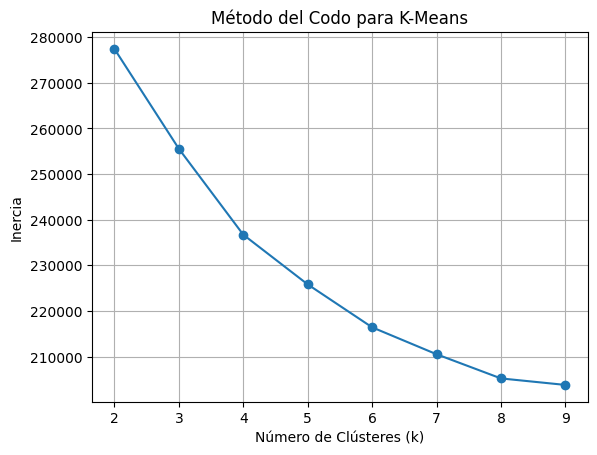

In [22]:
plt.plot(K, inertias, marker='o')
plt.xlabel("Número de Clústeres (k)")
plt.ylabel("Inercia")
plt.title("Método del Codo para K-Means")
plt.grid(True)
plt.show()


In [23]:
modelo_final = Pipeline([
    ('pre', preprocesador),
    ('kmeans', KMeans(n_clusters=4, random_state=42))
])


In [24]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

etiquetas = modelo_final.fit_predict(df)

df_pre = modelo_final.named_steps['pre'].transform(df)

silhouette = silhouette_score(df_pre, etiquetas)
calinski = calinski_harabasz_score(df_pre, etiquetas)
davies = davies_bouldin_score(df_pre, etiquetas)

silhouette, calinski, davies


InvalidParameterError: The 'X' parameter of calinski_harabasz_score must be an array-like. Got <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 348334 stored elements and shape (49762, 34)> instead.

In [25]:
df_dense = df_pre.toarray()


In [26]:
silhouette = silhouette_score(df_dense, etiquetas)
calinski = calinski_harabasz_score(df_dense, etiquetas)
davies = davies_bouldin_score(df_dense, etiquetas)

print("Silhouette:", silhouette)
print("Calinski-Harabasz:", calinski)
print("Davies-Bouldin:", davies)

Silhouette: 0.09995491269170743
Calinski-Harabasz: 5454.959927857411
Davies-Bouldin: 2.267572032003918


In [29]:
df_pre_dense = df_pre.toarray()


In [30]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

for k in [3, 4, 5]:
    kmeans_test = KMeans(n_clusters=k, random_state=42)
    labels_test = kmeans_test.fit_predict(df_pre_dense)

    sil = silhouette_score(df_pre_dense, labels_test)
    ch = calinski_harabasz_score(df_pre_dense, labels_test)
    db = davies_bouldin_score(df_pre_dense, labels_test)

    print(f"K={k} -> Silhouette: {sil}, CH: {ch}, DB: {db}")


K=3 -> Silhouette: 0.09512437793314796, CH: 5746.832486457899, DB: 2.4508540976024658
K=4 -> Silhouette: 0.09995573394980846, CH: 5454.962939051264, DB: 2.2675658909154905
K=5 -> Silhouette: 0.09082755994058578, CH: 4888.076863446357, DB: 2.2877484358483686


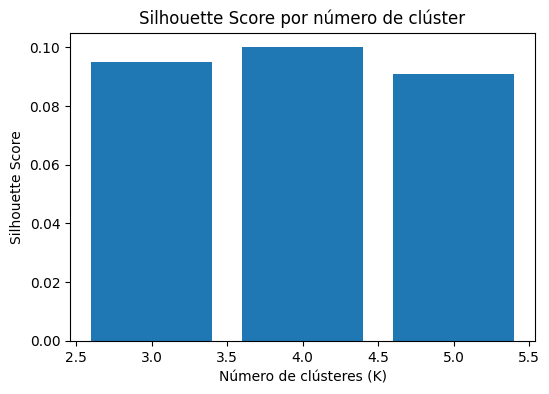

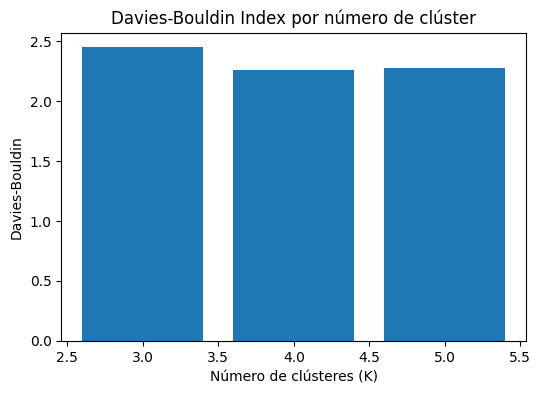

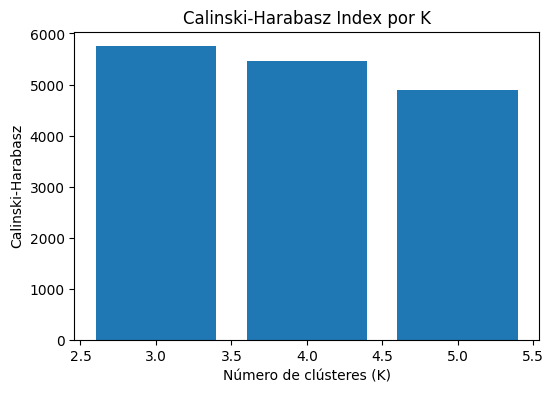

In [31]:
import matplotlib.pyplot as plt

# Valores
k_values = [3, 4, 5]
sil_values = [0.0951, 0.09995, 0.0908]
db_values = [2.45, 2.26, 2.28]
ch_values = [5746.83, 5454.96, 4888.07]

# Silhouette
plt.figure(figsize=(6,4))
plt.bar(k_values, sil_values)
plt.title("Silhouette Score por número de clúster")
plt.xlabel("Número de clústeres (K)")
plt.ylabel("Silhouette Score")
plt.show()

# Davies-Bouldin
plt.figure(figsize=(6,4))
plt.bar(k_values, db_values)
plt.title("Davies-Bouldin Index por número de clúster")
plt.xlabel("Número de clústeres (K)")
plt.ylabel("Davies-Bouldin")
plt.show()

# Calinski-Harabasz
plt.figure(figsize=(6,4))
plt.bar(k_values, ch_values)
plt.title("Calinski-Harabasz Index por K")
plt.xlabel("Número de clústeres (K)")
plt.ylabel("Calinski-Harabasz")
plt.show()


In [33]:
kmeans_final = KMeans(n_clusters=4, random_state=42)
etiquetas_finales = kmeans_final.fit_predict(df_pre_dense)


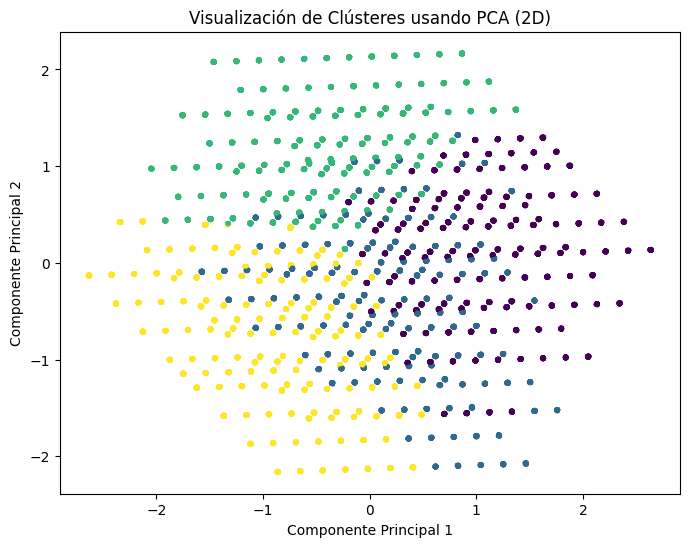

In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_pre_dense)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=etiquetas_finales, s=5)
plt.title("Visualización de Clústeres usando PCA (2D)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()
